
# **Customer Transactions Analysis**
### Exercise 5: Visualizing Spending Distribution
# 
#### This notebook analyzes the distribution of transaction amounts from synthetic customer transactions data.

In [6]:

# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime, timedelta
import random

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)



### **1. Generate Synthetic Customer Transactions Dataset**

##### We'll generate 100 transactions with the following attributes:
 - transaction_id (T0001-T0100)
 - transaction_date (Jan-Feb 2023)
 - transaction_amount
 - product_category (Electronics, Clothing, Grocery)
 - payment_method (Credit Card, Debit Card, Cash)

In [7]:
# %%
# Define constants and categories
num_transactions = 100
product_categories = ['Electronics', 'Clothing', 'Grocery']
payment_methods = ['Credit Card', 'Debit Card', 'Cash']

# Generate synthetic data
data = []
start_date = datetime(2023, 1, 1)

for i in range(num_transactions):
    # Generate unique transaction ID
    transaction_id = f"T{i+1:04d}"
    
    # Customer IDs from 1-50 (some customers will have multiple transactions)
    customer_id = random.randint(1, 50)
    
    # Random date between Jan 1, 2023 and Feb 28, 2023
    days_offset = random.randint(0, 58)  # 58 days from Jan 1 to Feb 28
    transaction_date = start_date + timedelta(days=days_offset)
    
    # Generate transaction amount based on product category
    category = random.choice(product_categories)
    
    if category == 'Electronics':
        # Electronics: Higher amounts, $50-$500
        transaction_amount = round(random.uniform(50, 500), 2)
    elif category == 'Clothing':
        # Clothing: Medium amounts, $20-$200
        transaction_amount = round(random.uniform(20, 200), 2)
    else:  # Grocery
        # Grocery: Lower amounts, $5-$100
        transaction_amount = round(random.uniform(5, 100), 2)
    
    # Assign payment method
    payment_method = random.choice(payment_methods)
    
    data.append({
        'customer_id': customer_id,
        'transaction_id': transaction_id,
        'transaction_date': transaction_date.strftime('%Y-%m-%d'),
        'transaction_amount': transaction_amount,
        'product_category': category,
        'payment_method': payment_method
    })

# Create DataFrame
df = pd.DataFrame(data)

# Display first 15 rows
print("First 15 transactions:")
print(df.head(15).to_string(index=False))
print("\n" + "="*80)

First 15 transactions:
 customer_id transaction_id transaction_date  transaction_amount product_category payment_method
          41          T0001       2023-01-08              383.70      Electronics    Credit Card
          15          T0002       2023-01-09               14.74          Grocery           Cash
          35          T0003       2023-01-06               45.08          Grocery    Credit Card
           6          T0004       2023-01-14              277.41      Electronics    Credit Card
          36          T0005       2023-01-13               66.74          Grocery           Cash
          27          T0006       2023-01-15              126.07         Clothing    Credit Card
          49          T0007       2023-02-21              364.16      Electronics     Debit Card
          18          T0008       2023-01-10              480.75      Electronics     Debit Card
           7          T0009       2023-01-06               37.41         Clothing     Debit Card
       


### **2. Dataset Summary Statistics**

In [8]:
# Basic dataset info
print("DATASET OVERVIEW")
print("="*60)
print(f"Total number of transactions: {len(df):,}")
print(f"Date range: {df['transaction_date'].min()} to {df['transaction_date'].max()}")
print(f"Number of unique customers: {df['customer_id'].nunique():,}")
print(f"Total amount spent: ${df['transaction_amount'].sum():,.2f}")
print(f"Average transaction amount: ${df['transaction_amount'].mean():,.2f}")
print(f"Median transaction amount: ${df['transaction_amount'].median():,.2f}")
print(f"Minimum transaction amount: ${df['transaction_amount'].min():,.2f}")
print(f"Maximum transaction amount: ${df['transaction_amount'].max():,.2f}")
print(f"Transaction amount standard deviation: ${df['transaction_amount'].std():,.2f}")

print("\n" + "="*60)
print("TRANSACTIONS BY PRODUCT CATEGORY")
print("="*60)
category_counts = df['product_category'].value_counts()
for category, count in category_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{category}: {count} transactions ({percentage:.1f}%)")

print("\n" + "="*60)
print("TRANSACTIONS BY PAYMENT METHOD")
print("="*60)
payment_counts = df['payment_method'].value_counts()
for method, count in payment_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{method}: {count} transactions ({percentage:.1f}%)")



DATASET OVERVIEW
Total number of transactions: 100
Date range: 2023-01-03 to 2023-02-27
Number of unique customers: 45
Total amount spent: $14,732.65
Average transaction amount: $147.33
Median transaction amount: $91.67
Minimum transaction amount: $5.92
Maximum transaction amount: $486.05
Transaction amount standard deviation: $137.27

TRANSACTIONS BY PRODUCT CATEGORY
Electronics: 37 transactions (37.0%)
Grocery: 36 transactions (36.0%)
Clothing: 27 transactions (27.0%)

TRANSACTIONS BY PAYMENT METHOD
Credit Card: 39 transactions (39.0%)
Cash: 33 transactions (33.0%)
Debit Card: 28 transactions (28.0%)


### **3. Exercise 5: Visualizing Spending Distribution**
 
Create histograms and density plots to visualize the distribution of transaction amounts.


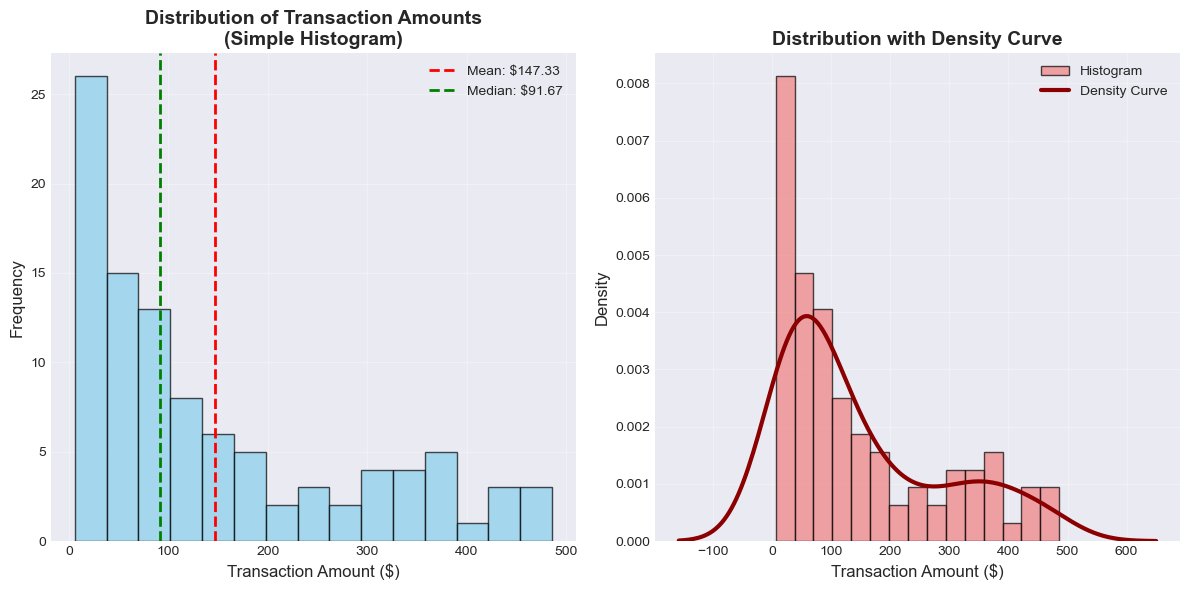

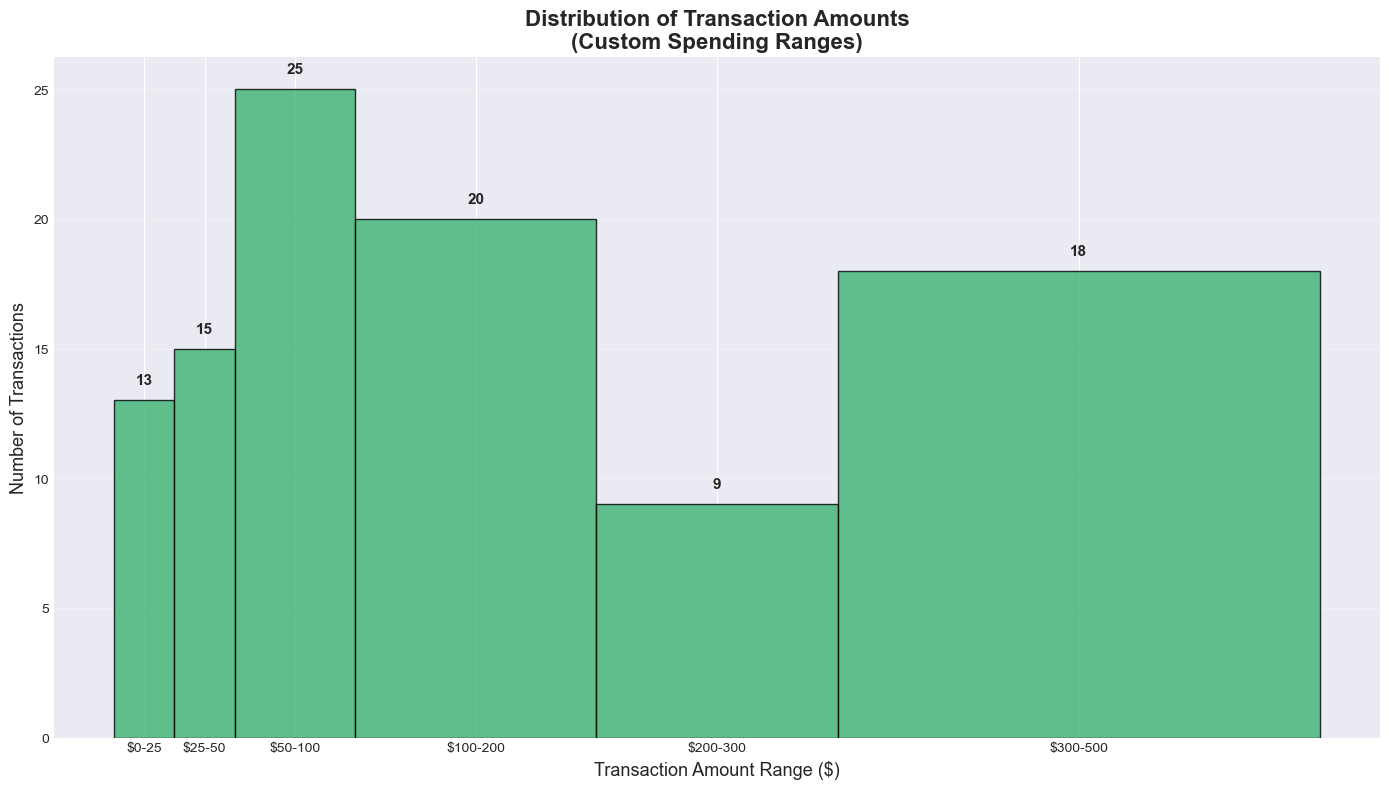

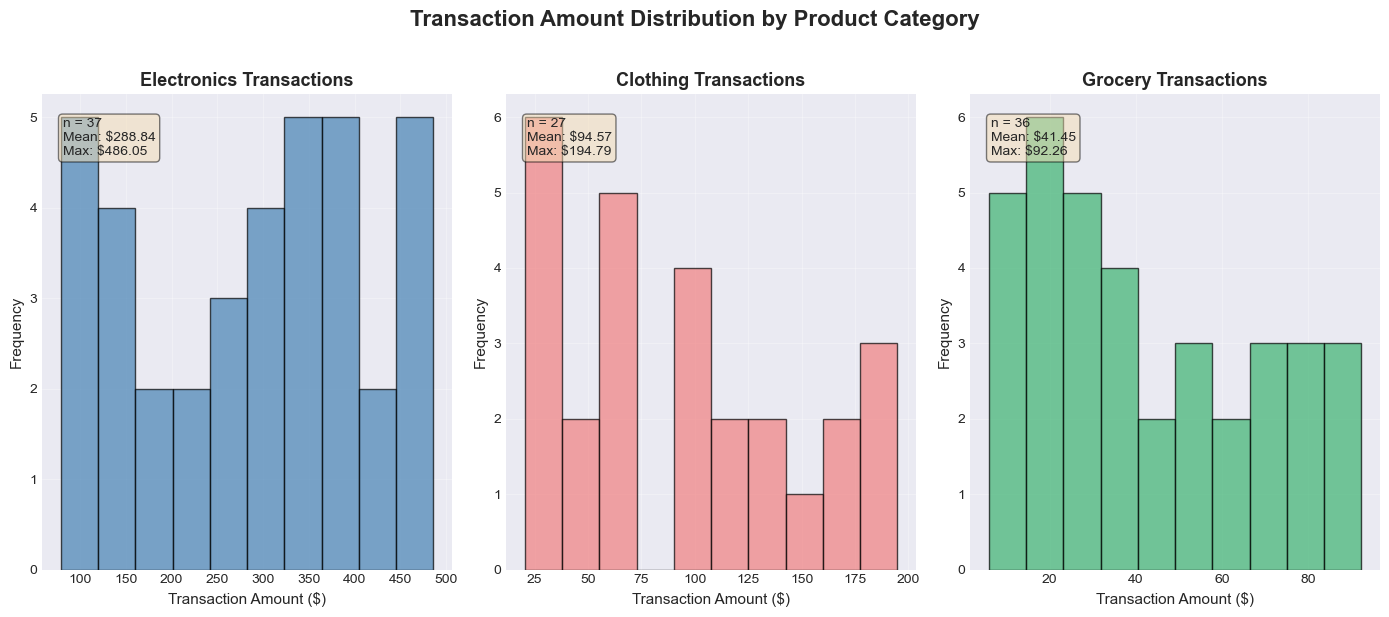

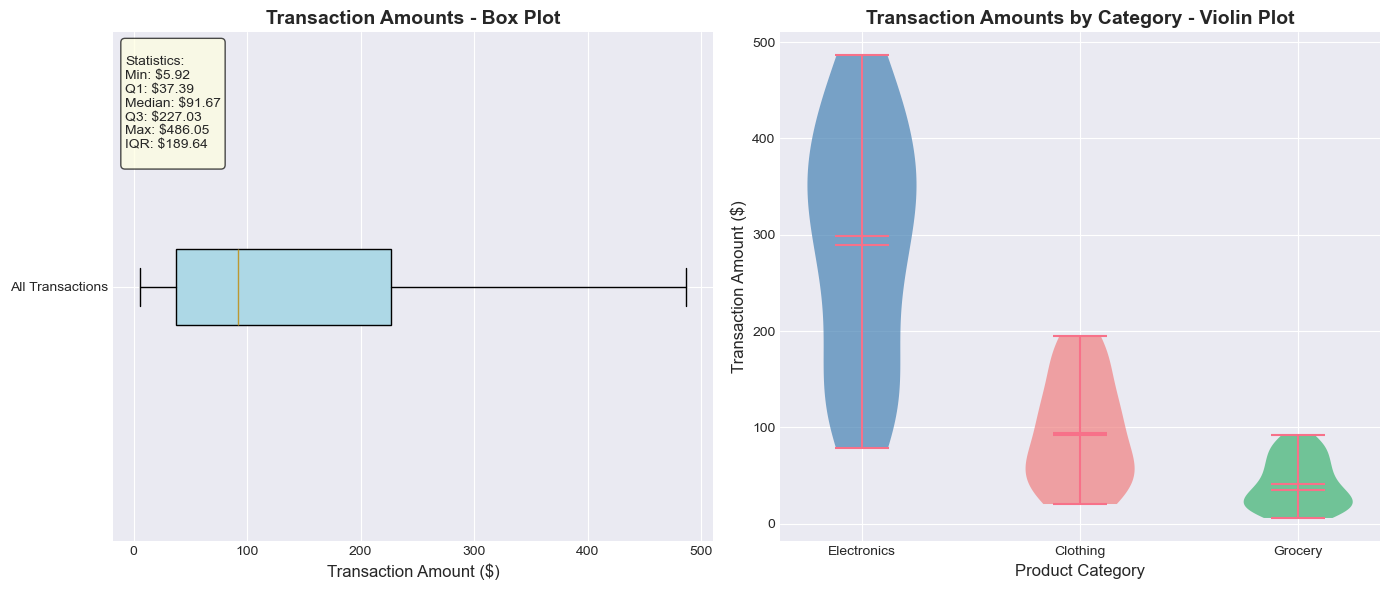

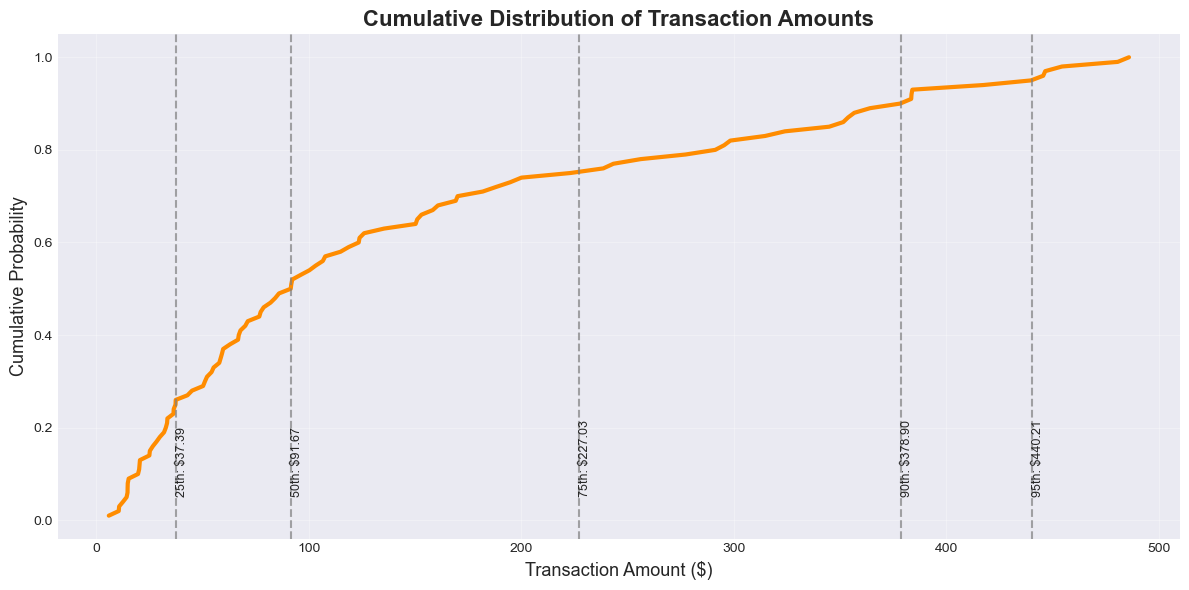

In [9]:
# Extract transaction amounts for visualization
transaction_amounts = df['transaction_amount'].values

# %%
# Basic histogram
plt.figure(figsize=(12, 6))

# Plot 1: Simple histogram
plt.subplot(1, 2, 1)
plt.hist(transaction_amounts, bins=15, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Distribution of Transaction Amounts\n(Simple Histogram)', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

# Add vertical lines for mean and median
plt.axvline(df['transaction_amount'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: ${df["transaction_amount"].mean():.2f}')
plt.axvline(df['transaction_amount'].median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median: ${df["transaction_amount"].median():.2f}')
plt.legend()

# Plot 2: Histogram with density curve
plt.subplot(1, 2, 2)
plt.hist(transaction_amounts, bins=15, edgecolor='black', alpha=0.7, 
         density=True, color='lightcoral', label='Histogram')

# Add KDE (Kernel Density Estimate)
sns.kdeplot(transaction_amounts, color='darkred', linewidth=3, label='Density Curve')

plt.title('Distribution with Density Curve', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Amount ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# %%
# Advanced histogram with custom bins
plt.figure(figsize=(14, 8))

# Define custom bins based on spending ranges
bins = [0, 25, 50, 100, 200, 300, 500]
bin_labels = ['$0-25', '$25-50', '$50-100', '$100-200', '$200-300', '$300-500']

plt.hist(transaction_amounts, bins=bins, edgecolor='black', alpha=0.8, color='mediumseagreen')
plt.title('Distribution of Transaction Amounts\n(Custom Spending Ranges)', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Amount Range ($)', fontsize=13)
plt.ylabel('Number of Transactions', fontsize=13)

# Customize x-axis labels
plt.xticks(ticks=[(bins[i] + bins[i+1])/2 for i in range(len(bins)-1)], 
           labels=bin_labels, rotation=0)

# Add value labels on top of bars
counts, bin_edges = np.histogram(transaction_amounts, bins=bins)
for i, count in enumerate(counts):
    plt.text((bin_edges[i] + bin_edges[i+1])/2, count + 0.5, str(count), 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# %%
# Distribution by product category
plt.figure(figsize=(14, 6))

colors = {'Electronics': 'steelblue', 'Clothing': 'lightcoral', 'Grocery': 'mediumseagreen'}

for i, category in enumerate(product_categories):
    category_amounts = df[df['product_category'] == category]['transaction_amount']
    
    plt.subplot(1, 3, i+1)
    plt.hist(category_amounts, bins=10, edgecolor='black', alpha=0.7, color=colors[category])
    plt.title(f'{category} Transactions', fontsize=13, fontweight='bold')
    plt.xlabel('Transaction Amount ($)', fontsize=11)
    plt.ylabel('Frequency', fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Add statistics
    plt.text(0.05, 0.95, f'n = {len(category_amounts)}\nMean: ${category_amounts.mean():.2f}\nMax: ${category_amounts.max():.2f}', 
             transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Transaction Amount Distribution by Product Category', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# %%
# Box plot and violin plot for comparison
plt.figure(figsize=(14, 6))

# Plot 1: Box plot
plt.subplot(1, 2, 1)
box = plt.boxplot(transaction_amounts, vert=False, patch_artist=True, 
                  boxprops=dict(facecolor='lightblue'))
plt.title('Transaction Amounts - Box Plot', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Amount ($)', fontsize=12)
plt.yticks([1], ['All Transactions'])

# Add summary statistics
stats_text = f"""
Statistics:
Min: ${df['transaction_amount'].min():.2f}
Q1: ${df['transaction_amount'].quantile(0.25):.2f}
Median: ${df['transaction_amount'].median():.2f}
Q3: ${df['transaction_amount'].quantile(0.75):.2f}
Max: ${df['transaction_amount'].max():.2f}
IQR: ${df['transaction_amount'].quantile(0.75) - df['transaction_amount'].quantile(0.25):.2f}
"""
plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Plot 2: Violin plot by product category
plt.subplot(1, 2, 2)
violin_data = [df[df['product_category'] == cat]['transaction_amount'] for cat in product_categories]
violin = plt.violinplot(violin_data, showmeans=True, showmedians=True)
plt.title('Transaction Amounts by Category - Violin Plot', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Transaction Amount ($)', fontsize=12)
plt.xticks([1, 2, 3], product_categories)

# Color the violins
for i, pc in enumerate(violin['bodies']):
    pc.set_facecolor(list(colors.values())[i])
    pc.set_alpha(0.7)

plt.tight_layout()
plt.show()

# %%
# Cumulative distribution function (CDF)
plt.figure(figsize=(12, 6))

# Sort transaction amounts
sorted_amounts = np.sort(transaction_amounts)
cdf = np.arange(1, len(sorted_amounts) + 1) / len(sorted_amounts)

plt.plot(sorted_amounts, cdf, linewidth=3, color='darkorange')
plt.title('Cumulative Distribution of Transaction Amounts', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Amount ($)', fontsize=13)
plt.ylabel('Cumulative Probability', fontsize=13)
plt.grid(True, alpha=0.3)

# Add reference lines for key percentiles
percentiles = [25, 50, 75, 90, 95]
for p in percentiles:
    percentile_value = np.percentile(transaction_amounts, p)
    plt.axvline(percentile_value, color='gray', linestyle='--', alpha=0.7)
    plt.text(percentile_value, 0.05, f'{p}th: ${percentile_value:.2f}', 
             rotation=90, verticalalignment='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### **4. Insights and Analysis**

Calculate key insights from the distribution

In [10]:
# Calculate key insights from the distribution
print("SPENDING DISTRIBUTION INSIGHTS")
print("="*60)

# Skewness and kurtosis
from scipy.stats import skew, kurtosis
skewness = skew(transaction_amounts)
kurt = kurtosis(transaction_amounts)

print(f"Distribution Skewness: {skewness:.3f}")
if skewness > 0.5:
    print("  → Right-skewed distribution (positive skew)")
    print("  → Most transactions are lower than the mean")
elif skewness < -0.5:
    print("  → Left-skewed distribution (negative skew)")
    print("  → Most transactions are higher than the mean")
else:
    print("  → Approximately symmetric distribution")

print(f"\nDistribution Kurtosis: {kurt:.3f}")
if kurt > 3:
    print("  → Leptokurtic (heavy-tailed)")
    print("  → More extreme values than normal distribution")
elif kurt < 3:
    print("  → Platykurtic (light-tailed)")
    print("  → Fewer extreme values than normal distribution")
else:
    print("  → Mesokurtic (similar to normal distribution)")

# Spending segments based on distribution
q1 = np.percentile(transaction_amounts, 25)
median = np.percentile(transaction_amounts, 50)
q3 = np.percentile(transaction_amounts, 75)

print("\n" + "="*60)
print("SPENDING SEGMENTS BASED ON DISTRIBUTION QUARTILES")
print("="*60)
print(f"Bottom 25% (Low spenders): < ${q1:.2f}")
print(f"Middle 50% (Medium spenders): ${q1:.2f} - ${q3:.2f}")
print(f"Top 25% (High spenders): > ${q3:.2f}")

# Count transactions in each segment
low_count = len(df[df['transaction_amount'] < q1])
medium_count = len(df[(df['transaction_amount'] >= q1) & (df['transaction_amount'] <= q3)])
high_count = len(df[df['transaction_amount'] > q3])

print(f"\nTransaction Count by Segment:")
print(f"Low spenders: {low_count} transactions ({low_count/len(df)*100:.1f}%)")
print(f"Medium spenders: {medium_count} transactions ({medium_count/len(df)*100:.1f}%)")
print(f"High spenders: {high_count} transactions ({high_count/len(df)*100:.1f}%)")


SPENDING DISTRIBUTION INSIGHTS
Distribution Skewness: 1.020
  → Right-skewed distribution (positive skew)
  → Most transactions are lower than the mean

Distribution Kurtosis: -0.243
  → Platykurtic (light-tailed)
  → Fewer extreme values than normal distribution

SPENDING SEGMENTS BASED ON DISTRIBUTION QUARTILES
Bottom 25% (Low spenders): < $37.39
Middle 50% (Medium spenders): $37.39 - $227.03
Top 25% (High spenders): > $227.03

Transaction Count by Segment:
Low spenders: 25 transactions (25.0%)
Medium spenders: 50 transactions (50.0%)
High spenders: 25 transactions (25.0%)


### **5. Additional Visualizations**


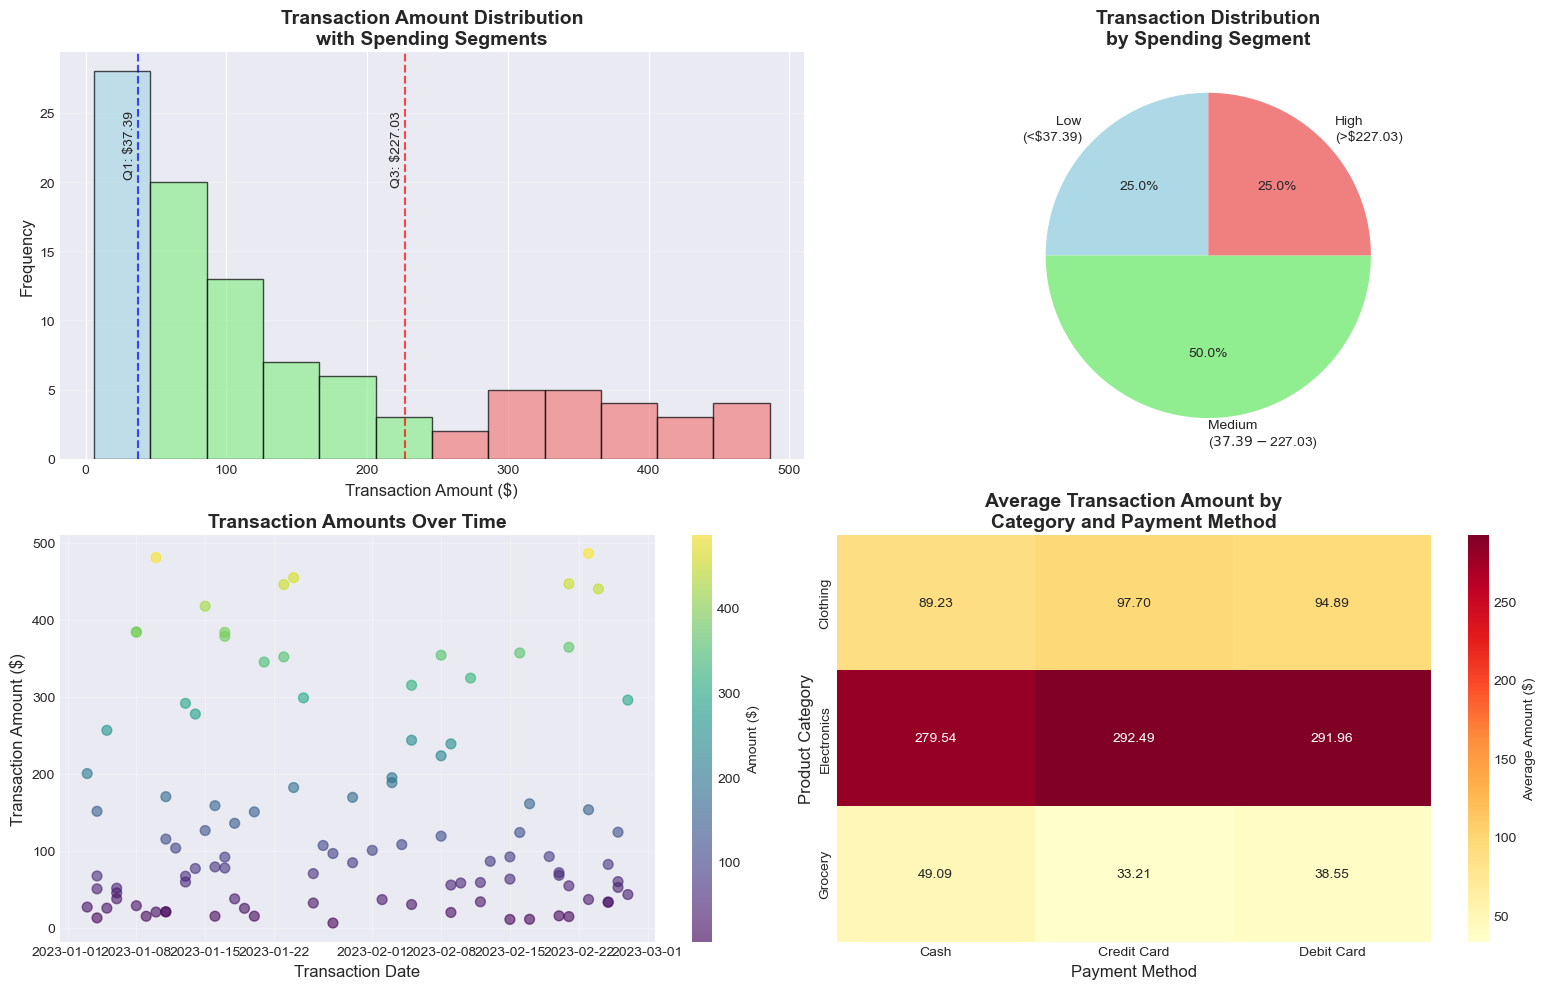

In [11]:
# %%
# Multi-panel visualization
fig = plt.figure(figsize=(16, 10))

# Panel 1: Histogram with spending segments highlighted
ax1 = plt.subplot(2, 2, 1)
n, bins, patches = plt.hist(transaction_amounts, bins=12, edgecolor='black', alpha=0.7)

# Color bars by spending segment
for i, patch in enumerate(patches):
    bin_center = (bins[i] + bins[i+1]) / 2
    if bin_center < q1:
        patch.set_facecolor('lightblue')  # Low spenders
    elif bin_center <= q3:
        patch.set_facecolor('lightgreen')  # Medium spenders
    else:
        patch.set_facecolor('lightcoral')  # High spenders

plt.title('Transaction Amount Distribution\nwith Spending Segments', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Add segment lines and labels
plt.axvline(q1, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axvline(q3, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.text(q1-10, max(n)*0.9, f'Q1: ${q1:.2f}', rotation=90, verticalalignment='top', fontsize=10)
plt.text(q3-10, max(n)*0.9, f'Q3: ${q3:.2f}', rotation=90, verticalalignment='top', fontsize=10)

# Panel 2: Pie chart of spending segments
ax2 = plt.subplot(2, 2, 2)
segment_sizes = [low_count, medium_count, high_count]
segment_labels = [f'Low\n(<${q1:.2f})', f'Medium\n(${q1:.2f}-${q3:.2f})', f'High\n(>${q3:.2f})']
segment_colors = ['lightblue', 'lightgreen', 'lightcoral']
plt.pie(segment_sizes, labels=segment_labels, colors=segment_colors, autopct='%1.1f%%', 
        startangle=90, textprops={'fontsize': 10})
plt.title('Transaction Distribution\nby Spending Segment', fontsize=14, fontweight='bold')

# Panel 3: Scatter plot of transaction amounts over time
ax3 = plt.subplot(2, 2, 3)
df['transaction_date_dt'] = pd.to_datetime(df['transaction_date'])
plt.scatter(df['transaction_date_dt'], df['transaction_amount'], alpha=0.6, 
            c=df['transaction_amount'], cmap='viridis', s=50)
plt.title('Transaction Amounts Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Date', fontsize=12)
plt.ylabel('Transaction Amount ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Amount ($)')

# Panel 4: Heatmap of transaction amounts by category and payment method
ax4 = plt.subplot(2, 2, 4)
heatmap_data = df.groupby(['product_category', 'payment_method'])['transaction_amount'].mean().unstack()
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Average Amount ($)'})
plt.title('Average Transaction Amount by\nCategory and Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

plt.tight_layout()
plt.show()

### **Summary of Key Findings**
 
##### Based on the spending distribution analysis:
 
#### 1. **Distribution Shape**: The transaction amounts show a ______ distribution
#### (based on the calculated skewness of {skewness:.3f}).
   
#### 2. **Spending Segments**: 
- Low spenders (bottom 25%): Transactions below ${q1:.2f}
- Medium spenders (middle 50%): Transactions between ${q1:.2f} and ${q3:.2f}
- High spenders (top 25%): Transactions above ${q3:.2f}
#    
#### 3. **Category Differences**:
- Electronics transactions tend to be higher value
- Grocery transactions are generally lower value
- Clothing transactions fall in the middle range
   
#### 4. **Business Implications**:
- Marketing strategies can be tailored based on spending segments
- Product recommendations can be optimized based on transaction patterns
- Inventory management can be informed by typical transaction values per category

In [12]:
# %%
# Save the DataFrame to CSV for future use
df.to_csv('customer_transactions.csv', index=False)
print("Dataset saved to 'customer_transactions.csv'")

Dataset saved to 'customer_transactions.csv'
